# Module 4 — Prompt Engineering and Evaluation

## Setup

*these will be present in the beginning of all the notebooks to make sure the environment is setup correctly in Colab*

### Setup Notebook Environment

### Installing Python Libraries

**In Colab**, this might ask you to restart your session, do so and if you face issues that Gemini can't help you with ask the TA.

In [1]:
import pkg_resources
try:
    import google.colab
    IN_COLAB = True
    print("Running on Colab, let's run through the installs")
except ImportError:
    IN_COLAB = False
    print("Running locally, assuming you have a venv setup already done.")

def check_and_get_missing(requirements):
    to_install = []
    for pkg, ver in requirements.items():
        try:
            installed = pkg_resources.get_distribution(pkg).version
            if ver and installed != ver:
                print(f"Version mismatch for {pkg}: found {installed}, need {ver}")
                to_install.append(f"{pkg}=={ver}")
        except pkg_resources.DistributionNotFound:
            print(f"Package {pkg} not found.")
            to_install.append(f"{pkg}=={ver}" if ver else pkg)
    return to_install

if IN_COLAB:
    # 1. PYTORCH CHECK
    torch_reqs = {"torch": "2.2.0", "torchvision": "0.17.0", "torchaudio": "2.2.0"}
    missing_torch = check_and_get_missing(torch_reqs)
    if missing_torch:
        print("Uninstalling potentially conflicting torch packages...")
        !pip uninstall -y torch torchvision torchaudio
        print("Installing correct PyTorch versions...")
        !pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu121

    # 2. CORE LIBRARIES CHECK
    core_reqs = {
        "chromadb": "0.5.5",
        "transformers": "5.5.4",
        "numpy": "1.26.4",
        "posthog": "2.5.0",
        "ollama": None
    }
    missing_core = check_and_get_missing(core_reqs)
    if missing_core:
        print(f"Installing/Updating: {missing_core}")
        !pip install -U {' '.join(missing_core)}

    # 3. UNSLOTH CHECK
    try:
        import unsloth
    except ImportError:
        print("Installing Unsloth...")
        !pip install --no-cache-dir unsloth

    import torch
    print("Final Check - Torch:", torch.__version__, "CUDA:", torch.version.cuda)

/tmp/ipykernel_4316/3350433716.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


Running on Colab, let's run through the installs
Version mismatch for torch: found 2.2.0+cu121, need 2.2.0
Version mismatch for torchvision: found 0.17.0+cu121, need 0.17.0
Version mismatch for torchaudio: found 2.2.0+cu121, need 2.2.0
Uninstalling potentially conflicting torch packages...
Found existing installation: torch 2.2.0+cu121
Uninstalling torch-2.2.0+cu121:
  Successfully uninstalled torch-2.2.0+cu121
Found existing installation: torchvision 0.17.0+cu121
Uninstalling torchvision-0.17.0+cu121:
  Successfully uninstalled torchvision-0.17.0+cu121
Found existing installation: torchaudio 2.2.0+cu121
Uninstalling torchaudio-2.2.0+cu121:
  Successfully uninstalled torchaudio-2.2.0+cu121
Installing correct PyTorch versions...
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.2.0%2Bcu121-cp312-cp312-linux_x86_64.whl (757.2 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.17.0%2Bcu121-cp

Get Ollama (this is what we are using to interact with the model and manage it)

In [2]:
import subprocess
import os
import glob

def _is_already_installed(service_name: str) -> bool:
    result = subprocess.run(['which', service_name], capture_output=True)
    if result.returncode == 0:
        print(service_name, " already installed")
        return True
    return False

def find_course_dir_gdrive() -> str:
    matches = [
        os.path.dirname(m)
        for m in glob.glob('/content/drive/**/pyproject.toml', recursive=True)
        if 'applied-ml-course' in open(m).read()
    ]
    if not matches:
        return input("Please enter the correct path to 'student_scaffolding' folder in your Google Drive: ")
    return matches[0]


if IN_COLAB:
    !sudo apt-get install zstd
    if not _is_already_installed("ollama"):
        # Install Ollama
        !curl -fsSL https://ollama.com/install.sh | sh


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (2,119 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 122412 files and directories currently

Getting the data and making sure we are in the right root directory.

There are two recommended ways,
- Upload to drive from your local using "setup assistant"
- Use github with PAT token

While we have tried to accommodate different styles of working there might still be exceptions and ways of doing this that we might have skipped to test.

**Getting the PAT from Github**

[Documentation](https://dev.to/warnerbell/how-to-generate-a-github-personal-access-token-pat-1bg5)

Options:
  - Choose Classic Token
  - Give access to repo

In [3]:
if IN_COLAB:
    import os
    import subprocess
    import zipfile
    import getpass

    # ----------------------------
    # CONFIG
    # ----------------------------
    REPO_URL = "https://github.com/watspeed/language-models.git"
    TARGET_DIR = "/content/repo"

    # Optional: set to None or a branch name
    REPO_BRANCH = None  # or None for main

    # ----------------------------
    # MENU
    # ----------------------------
    print("""
    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    """)

    choice = input("Enter choice (1, 2, 3): ").strip()

    # ----------------------------
    # DRIVE (optional)
    # ----------------------------
    def try_drive():
        try:
            from google.colab import drive
            drive.mount('/content/drive')

            default_path = "/content/drive/MyDrive/watspeed_llm_course"
            if os.path.exists(default_path):
                print(f"📁 Default path found: {default_path}")
                return default_path

            print("🔄 Searching Google Drive...")

            path = find_course_dir_gdrive()  # optional external helper

            if path:
                print(f"📁 Drive found: {path}")
                return path

        except Exception as e:
            print("⚠️ Drive failed:", e)

        return None


    # ----------------------------
    # GIT (MAIN + BRANCH SUPPORT)
    # ----------------------------
    def try_git(repo_url, branch=None):
        try:
            if os.path.exists(TARGET_DIR):
                print("📁 Repo already exists, reusing...")
                return TARGET_DIR

            # default branch = main
            branch = branch or "main"

            print(f"🔄 Cloning repo (branch: {branch})...")

            def run_clone(url):
                return subprocess.run(
                    ["git", "clone", "--branch", branch, "--single-branch", url, TARGET_DIR],
                    text=True,
                    capture_output=True
                )

            # 1) try public clone
            result = run_clone(repo_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("⚠️ Public clone failed. Trying PAT...")

            # 2) PAT fallback
            token = getpass.getpass("🔐 Enter GitHub PAT: ")

            auth_url = repo_url.replace(
                "https://", f"https://{token}:x-oauth-basic@"
            )

            result = run_clone(auth_url)

            if result.returncode == 0:
                return TARGET_DIR

            print("❌ Git clone failed")
            print(result.stderr)
            return None

        except Exception as e:
            print("⚠️ Git error:", e)
            return None


    # ----------------------------
    # ZIP IMPORT
    # ----------------------------
    def try_zip():
        print("📦 Upload ZIP...")
        from google.colab import files

        uploaded = files.upload()
        if not uploaded:
            print("⚠️ No file uploaded")
            return None

        zip_file = list(uploaded.keys())[0]

        try:
            with zipfile.ZipFile(zip_file, 'r') as z:
                z.extractall("/content")
        except zipfile.BadZipFile:
            print("❌ Invalid ZIP file")
            return None

        folder = zip_file.replace(".zip", "")
        path = os.path.join("/content", folder)

        print(f"📁 Extracted: {path}")
        return path


    # ----------------------------
    # MAIN LOGIC
    # ----------------------------
    project_path = None

    if choice == "2":
        project_path = try_git(REPO_URL, REPO_BRANCH)

    elif choice == "3":
        project_path = try_zip()

    else:
        # AUTO MODE
        project_path = try_drive()

        if not project_path:
            project_path = try_git(REPO_URL, REPO_BRANCH)

        if not project_path:
            project_path = try_zip()


    # ----------------------------
    # FINAL STEP
    # ----------------------------
    if project_path and os.path.exists(project_path):
        try:
            os.chdir(project_path)
            print("✅ Active directory:", os.getcwd())
            print("📂 Contents:", os.listdir())
        except Exception as e:
            print("❌ Failed to switch directory:", e)
    else:
        print("❌ No project loaded")

else:
    def in_root_folder() -> bool:
        return os.path.isdir("notebooks") and os.path.isdir("data")

    if not in_root_folder():
        import os
        os.chdir("..")


    📦 Project Loader Options:

    1 - Auto (Drive → Git → ZIP)
    2 - Git only
    3 - ZIP upload
    
Enter choice (1, 2, 3): 2
🔄 Cloning repo (branch: fix/technical-issues-review)...
⚠️ Public clone failed. Trying PAT...
🔐 Enter GitHub PAT: ··········
✅ Active directory: /content/repo
📂 Contents: ['CLAUDE.md', 'README.md', '.git', 'src', 'notebook_image_catalogue.md', 'uv.lock', 'notebooks', 'upload_to_colab.sh', '.claude', 'pyproject.toml', '.gitignore', 'technical_issues.md', 'prompts', 'course_setup.md', 'data', 'project_structure.md', '.python-version']


In [4]:
from IPython.display import display, Markdown

### Start Ollama and Load the Model

In [5]:
if IN_COLAB:
    import subprocess, time
    subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(3)  # give it a moment to start

!ollama pull gemma2:2b

In [6]:
import ollama

ollama.generate(
    model="gemma2:2b",
    prompt="hi, who is out there?"
).response

'Hello! I am Gemma, an AI assistant here to help you.  😊 \n\nHow can I be of assistance today? \n'

---

## Mastering LLM Behavior

Over the past three weeks we've built up the context about the machinery:

- Module 1, what LLMs are and how they generate text.
- Module 2, how text becomes tokens and embeddings.
- Module 3, how attention lets the model reach across a context window.

A base model like `gemma2:2b` or even larger models will respond to anything — but not necessarily in a useful, parseable, or reliable  way that is not an error but by design how the model works.

But, This behavior is not evident when using applications like Claude or GPT-4 the responses are fairly polished this is because they have invested in a lot of harness around the model, data gathering and fine-tuning to optimize the application for different contexts.

At its core, the model is doing the same thing as our *small* `gemma2:2b`. This week we will embark on the journey of: how do we get a model to consistently do what we want it to do?

The answer is a progression of methods, starting from the cheapest — crafting the prompt — and building toward more powerful approaches.

Before we begin, here's the full map.

## Fine-Tuning Methods: The Landscape

Before diving into prompt engineering, here is the full map of tuning methods — what exists, what it costs, and when each is worth reaching for and note these are approximates for models of similar size to `gemma2:2b` and especially methods requiring GPU can vary significantly with the size of the model and architecture.

| Tuning Method | Category | Description | Prerequisites | Compute / Hardware | When it's useful |
|---|---|---|---|---|---|
| **Prompt Engineering** | Prompt-level | Craft system/user/assistant messages to guide behavior | A prompt | CPU / none | Always — start here |
| **Few-shot Prompting** | Prompt-level | Embed example input→output pairs in the prompt | Prompt + examples | CPU / none | Zero-shot output is inconsistent |
| **RAG** | Prompt-level | Retrieve relevant context at inference time | Prompt + retrieval index | CPU–medium GPU | Domain knowledge the model doesn't have |
| **Distillation** | Distillation | Use a teacher model to generate labels; train a student model on them | Teacher model + unlabeled inputs | API / GPU (teacher once, student always) | Scale labeling cheaply; covered this week (eval set) |
| **Adapters / LoRA (with optional 4-bit quantization, aka QLoRA)** | Adapter | Fine-tune a small set of added weights; quantise the frozen base model to 4-bit when GPU memory is tight | Eval set + labeled pairs | Consumer GPU (6–16 GB) | prompt engineering can't close the gap ← **Module 5** |
| **SFT** | Full fine-tune | Retrain all model weights on labeled data | Large labeled dataset | Multi-GPU cluster | ❌ Out of scope — resource-intensive |
| **RLHF** | Full fine-tune | Reinforcement learning from human preferences | Preferences + reward model | Multi-GPU cluster | ❌ Out of scope — resource-intensive |

**The key insight:** every method past the first two requires an eval set. Prompt engineering is both the cheapest path *and* the prerequisite for knowing whether stronger methods are worth the cost.

Weeks 1–3 gave us the building blocks: how LLMs generate text, how tokenization shapes the input space, and how transformers attend to context. This week we put those pieces to work. We'll tune our prompts systematically, build the evaluation infrastructure that makes tuning measurable, and use those results to decide whether to stay at the prompt layer or escalate to adapters and fine-tuning.

---
## Prompts, Evaluation, and Improving Our Solution


### Problem Statement: Classifying Recipes into Time Categories

We want to classify recipes into time categories based on the skill level of the person searching the recipe to enrich the data with time categories so that we can easily filter out recipes based on time the user has and suggest recipes that are doable in the time that they have.


### The Data

We're working with a web-scraped recipe dataset. The cell below loads it and shows the columns — here's what matters for our problem:

| Column | Role |
|---|---|
| **Name** | Recipe title — a coarse signal the model can use to guess complexity |
| **Ingredients** | Full ingredient list — encodes technique indirectly (e.g., "temper chocolate", "masa harina") |
| **directions** | Step-by-step instructions — the richest signal for skill-sensitivity |
| **total_mins** / **prep_mins** / **cook_mins** | Author-stated times — the source of our pseudo-labels |
| **Category Code** | A, B, or C — derived from `total_mins`; this is what we're predicting |

The three categories map onto real cooking scenarios:
- **A — Quick (≤ 30 min):** Weeknight staples, assembly dishes, no waiting
- **B — Medium (30–60 min):** Sunday meals, one-pot dishes
- **C — Long (> 60 min):** Weekend projects, braised or baked dishes with resting time

One caveat we carry through the whole notebook: these times reflect what the *recipe author* expected. A beginner will almost always take longer — and that gap between author-stated time and actual experienced time is exactly what our classifier tries to model. That's why skill level is an input, not just a footnote.

In [7]:
import pandas as pd

recipes = pd.read_csv("data/All_Recipe_Web_Scraping_Dataset_With_Directions.csv")
print(recipes.columns)

columns = ["Name", "Description", "Servings", "Ingredients", "Prep Time", "Cook Time",  "Total Time", "directions"]
recipes[columns].head()

Index(['Name', 'Rating', 'Description', 'Prep Time', 'Cook Time', 'Total Time',
       'Servings', 'Ingredients', 'Image URL', 'prep_mins', 'cook_mins',
       'total_mins', 'wait_mins', 'Category Code', 'Category Name',
       'Category Description', 'directions'],
      dtype='object')


,Name,Description,Servings,Ingredients,Prep Time,Cook Time,Total Time,directions
0,Chicken Souvlaki with Tzatziki Sauce,Chicken souvlaki skewers are marinated Greek k...,6,"¼ cup olive oil | 2 cloves garlic, minced | 2 ...",15 mins,15 mins,2 hrs 30 mins,"- Combine 1/4 cup olive oil, lemon juice, 2 cl..."
1,Bacon-Wrapped Cherries,This recipe for bacon-wrapped cherries makes o...,18,"36 maraschino cherries, stemmed, drained and j...",20 mins,5 mins,25 mins,NaN
2,Meatless Mincemeat Pie,This meatless mincemeat pie is a sweet treat! ...,8,1 (18 ounce) jar prepared mincemeat pie fillin...,30 mins,40 mins,9 hrs 10 mins,"- Combine mincemeat, walnuts, apples, brown su..."
3,Vegetable Quesadillas,Delicious quesadillas with cheese and steamed ...,2,"1 zucchini, cubed | 1 head fresh broccoli, cho...",10 mins,30 mins,40 mins,"- Combine sweet pepper, leek, jalapeno, garlic..."
4,Dad's Lima Bean Soup with Ham Bone,This lima bean soup was one of my father's fav...,8,"1 ham bone with some meat | 8 cups water, plus...",20 mins,4 hrs 10 mins,5 hrs 30 mins,- Place beans in a large pot; cover with 2 inc...


### Classifying Recipes by Time

What makes this harder than it looks: **the same recipe takes different amounts of time depending on who is making it.**

Most cake recipes list 20 minutes of prep time, but that assumes we already know what properly creamed butter looks like, or when a dough is kneaded enough. A beginner will spend twice that time on the same step — not because the recipe is wrong, but because they are navigating a process that is entirely new to them.

Let's start with the simplest form for our classifier **two inputs**:
1. The recipe content (name + ingredients + directions)
2. The **cook's skill level** (beginner / intermediate / expert)

| Field | Content |
|---|---|
| **Recipe Name** | Banana Bread |
| **Skill level** | beginner |
| **Directions** | *"Mash bananas until smooth. Fold in dry ingredients until just combined — do not overmix."* |
| **→ Output** | **C — Long** *(a beginner won't know what "just combined" means until they've ruined a loaf)* |

The same recipe for an **expert** cook → **A — Quick**.

<!-- DIAGRAM: problem-statement-overview.png -->


In [8]:
# Below is a sample recipe
sample = recipes[recipes["Category Code"] == "A"].dropna(subset=["directions"]).iloc[0]

print(f"Name:     {sample['Name']}")
print(f"Category: {sample['Category Code']} — {sample['Category Name']}")
print(f"\nIngredients:\n{sample['Ingredients'][:300]}...")
print(f"\nDirections:\n{sample['directions'][:400]}...")

Name:     Asian Broccoli Slaw
Category: A — Quick, No-Wait

Ingredients:
2 (3 ounce) packages any flavor ramen noodles | ½ cup sunflower seeds | 1 (16 ounce) package broccoli coleslaw mix | ½ cup chopped fresh pineapple | ½ cup chopped fresh cilantro (Optional) | 2 green onions (white and green parts), chopped, or more to taste | ½ cup white sugar | ½ cup cider vinegar |...

Directions:
- Combine the cider vinegar, brown sugar, oil and one packet of the seasoning mix from the ramen noodles and let sit while preparing noodles.
- Crush the ramen noodles by placing in zip-lock bag and roll with rolling pin or anything that will work - this is very easy to do.
- "Lightly" brown the noodles and the slivered almonds in frying pan with two tablespoons of olive or canola oil - do not sco...


---
### The Anatomy of a Prompt

Every call to `ollama.chat()` sends a list of **messages**, each with a `role`. The role controls where in the model's token context the content lands — and because the model reads left-to-right (Module 3), position determines influence.



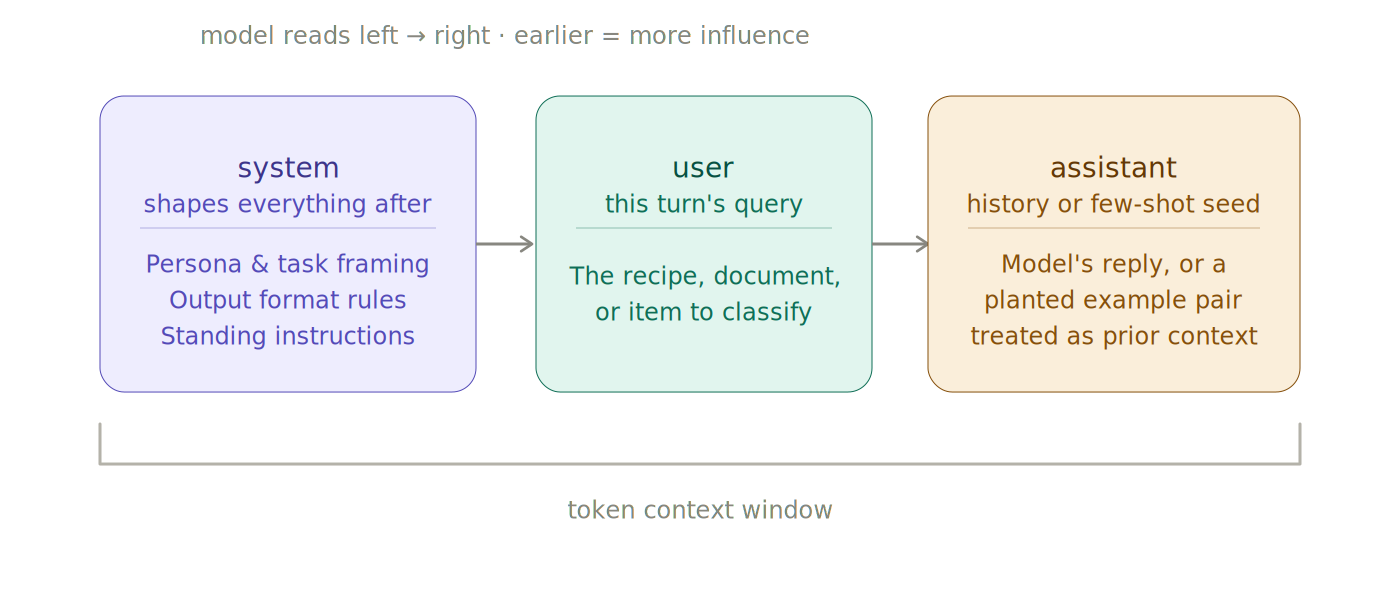
> **[Diagram Caption]** The anatomy of a chat prompt showing three message roles stacked in order: the system message at the top sets the model’s persona and task constraints, the user message carries the input, and an optional assistant message can prime the response format. Position in the context window determines how strongly each part influences generation.



The three roles we will use:

- **system** — appears first in the context window. Use it for our task definition, persona, and output format rules. Whatever we put here shapes how the model reads every user message that follows.
- **user** — the query for this turn: the recipe text, the ingredient to substitute, the document to classify.
- **assistant** — the model's reply, or something we want the model assume it said, when we pre-fill an assistant turn before the real query, the model treats it as prior conversation and calibrates its next answer to match the pattern.


---
### Zero-Shot Prompt

Providing the model with only task instructions and no examples is called **zero-shot prompting** — our simplest baseline.

This is our **baseline to beat**.


In [9]:
import ollama

CATEGORIES = {
    "A": "Quick — total time ≤ 30 min",
    "B": "Medium — 30 to 60 min",
    "C": "Long — total time > 60 min (includes resting, braising, etc.)",
}


def prompt_v1(name: str, ingredients: str, directions: str,
                skill_level: str = "intermediate") -> str:
    """Zero-shot prompt"""
    prompt = f"""Recipe: {name}
        Cook's skill level: {skill_level}

        Ingredients:
        {ingredients}

        Directions:
        {directions}

        Provide the Time Category (A, B, or C) Below:
    """
    return prompt


def classify_v1(prompt: str) -> str:
    cats = " | ".join(f"{k}: {v}" for k, v in CATEGORIES.items())
    system_prompt = f"Given the cook's skill level, classify this recipe into a time category. Categories: {cats}"
    response = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ]
    )
    return response.message.content


print("beginner:", classify_v1(prompt_v1(sample["Name"], sample["Ingredients"], sample["directions"], "beginner")))
print("expert:", classify_v1(prompt_v1(sample["Name"], sample["Ingredients"], sample["directions"], "expert")))

beginner: This recipe would likely fall into **Category B: Medium** 

Here's why:

* **Preparation:**  It involves some minimal steps like crushing noodles, cooking them in oil, and assembling the slaw. These stages take about 15-20 minutes at a minimum for preparation.  
* **Waiting Time:** The recipe suggests letting the slaw "sit" which can be anywhere from 30 minutes to an hour or more, giving it time to develop flavors. 
* **Total Time:**  If you're including the waiting and cooking stages, the total time would fall somewhere in the middle of a medium-length preparation time.

Let me know if you have any other recipes you'd like me to categorize! 

expert: The time category for this recipe would be **B: Medium**. 

Here's why:

* **Time for preparation:**  Preparing the noodles, slicing ingredients, and combining with other components takes a moderate amount of time. 
* **Cooling and resting:** The recipe recommends letting the mixture sit to allow flavors to blend, which typicall

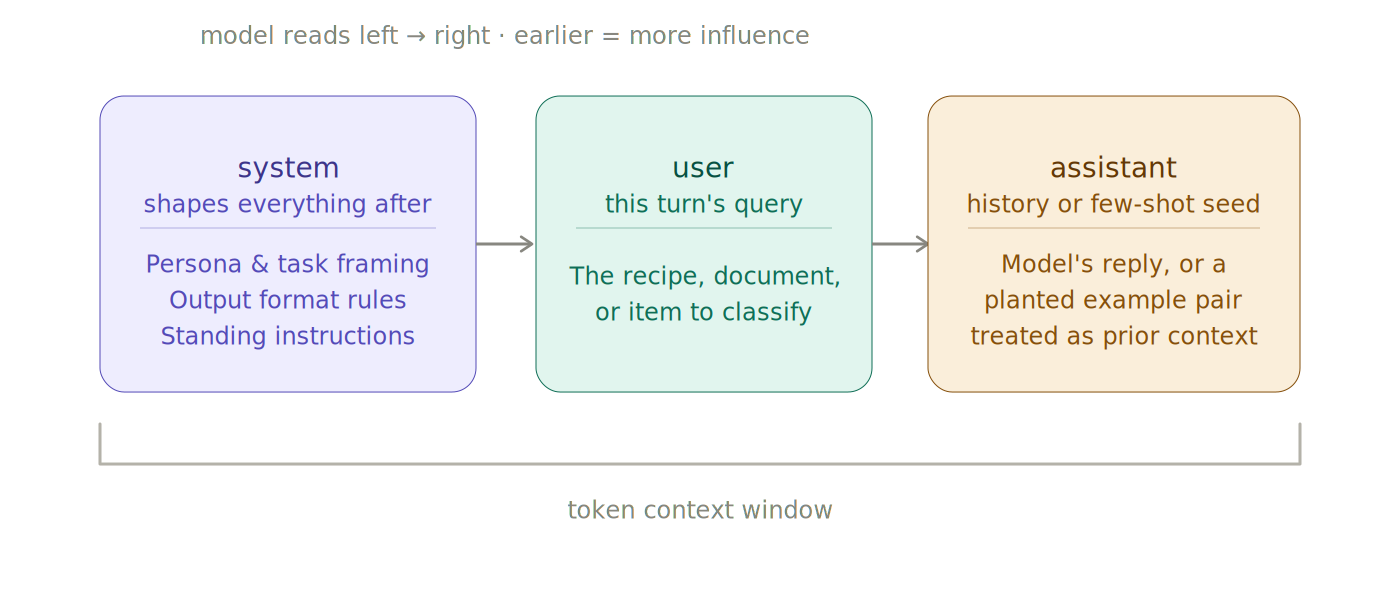
> **[Diagram Caption]** The same prompt anatomy diagram shown in context of the recipe classifier: a system message defines the time categories, the user message provides the recipe, and the model’s response is expected to be a single category label (A, B, or C).



<!-- DIAGRAM: zero-shot-prompt-structure.png -->


---
### Few-Shot Prompting

**Few-shot prompting** means including worked examples directly in the prompt — input/output pairs that show the model exactly what a correct answer looks like. Unlike zero-shot, where the model has only our instructions to go on, few-shot gives it a small reference set to pattern-match against. The model doesn't "learn" from these examples , i.e., no weights change, but they shift the distribution of its outputs toward the style, format, and boundaries we have demonstrated.

For our recipe classifier, what's still missing is a way to anchor the model on skill-sensitive *boundaries* — the cases where a small difference in technique knowledge moves a recipe from B to C.

That's what few-shot examples do. Instead of asking the model to reason from scratch every time, we show it concrete examples: "here's a recipe, here's the skill level, here's the right answer." The model uses those pairs to calibrate its sense of where the category lines fall.

Two things to notice in the few-shot pairs below:
1. **Same recipe, different skill levels can produce different labels** — Pasta Carbonara is B for an expert (who knows how to temper eggs off heat) but C for a beginner (who will likely scramble them and have to start over)
2. **Some recipes are the same regardless of skill** — Scrambled Eggs is A for both, and Croissants is C for both — the few-shot set needs to include those too, otherwise the model over-applies skill differentiation


<!-- DIAGRAM: few-shot-prompt-structure.png -->


In [10]:
def prompt_v2(name: str, ingredients: str, directions: str,
              skill_level: str = "intermediate") -> str:
    """Few-shot prompt: skill-aware examples embedded to anchor category boundaries."""
    examples = (
        "Skill: expert   | Scrambled Eggs    → A  (no technique-heavy steps)\n"
        "Skill: beginner | Scrambled Eggs    → A  (same — skill doesn't change this one)\n"
        "Skill: expert   | Croissants        → C  (lamination is slow even for experts)\n"
        "Skill: beginner | Croissants        → C  (same — overnight proof dominates)\n"
        "Skill: expert   | Pasta Carbonara   → B  (knows to temper eggs off heat)\n"
        "Skill: beginner | Pasta Carbonara   → C  (likely scrambles eggs, has to restart)\n"
    )
    return f"""Use these examples to calibrate where the category boundaries fall:
        {examples}
        Now classify:
        Recipe: {name}
        Cook's skill level: {skill_level}

        Ingredients:
        {ingredients}

        Directions:
        {directions}

        Given the cook's skill level, is this recipe quick (A), medium (B), or long (C) to make?
    """


# Smoke test
print("Beginner:", classify_v1(prompt_v2(sample["Name"], sample["Ingredients"], sample["directions"], "beginner")))
print("Expert:  ", classify_v1(prompt_v2(sample["Name"], sample["Ingredients"], sample["directions"], "expert")))

Beginner: Considering the cook's skill level and the recipe steps, **this recipe would fall into the "Medium" (B) time category.** Here's why:

* **Time-intensive components:**  The recipe involves some processes that require a bit more time than simply throwing ingredients together. 
    * **Crushing noodles:** This step requires manual effort and can be slightly time-consuming, depending on how the user prefers to crush them. 
    * **Heating & Cooling Noodles:**  While relatively quick, this process does take some time, particularly if you're not comfortable with a rolling pin or have limited space for a pan.

Let me know if you would like more details about why this recipe falls under "Medium" versus other categories! 😊 

Expert:   Based on your calibration and the provided recipe:

**Category: B - Medium**

**Reasoning:**

* **Quick steps:**  The recipe outlines clear instructions with a straightforward process. There isn't a lot of complex skill, technique, or extended time requi

---

**Optional Extension: Retrieval-Augmented Few-Shot Selection**

The few-shot examples above are hard-coded. In practice, the best examples for a given query are the ones most similar to it.

Try replacing the static examples with dynamically retrieved ones:
1. Use any embedding similarity method (e.g., the Module 3 ChromaDB store if you have it, or `sentence-transformers` cosine similarity) to find the 3 most similar labeled recipes to the current query.
2. Format those retrieved recipes as few-shot examples in the prompt.
3. Compare accuracy against the static few-shot approach.

This technique — *retrieval-augmented few-shot selection* — is a natural bridge between prompt engineering and the RAG pipeline we build in Module 6.

> **Token cost:** The skill-aware few-shot pairs are longer than before — about 6 pairs × ~40 tokens = ~240 extra prompt tokens per call. The token optimization section later in this notebook shows how to measure this and what to do when context gets expensive.

#### Structured Output

We can control what the LLM provides in response by providing the Ollama API (and most others) a json schema that it should adhere too, this changes the way the LLM is asked to respond by prefilling the initial text. We will be using pydantic for it below.


In [11]:
from pydantic import BaseModel
from typing import Literal


class ResponseV1(BaseModel):
    recipe_name: str
    time_category: Literal["A", "B", "C"]


def classify_v2(prompt: str) -> str:
    system_prompt = "Given the cook's skill level, is this recipe quick (A), medium (B), or long (C) to make?"
    response = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt}
        ],
        format=ResponseV1.model_json_schema(),
        options={"temperature": 0}
    )
    return response.message.content

print("beginner:", classify_v2(prompt_v1(sample["Name"], sample["Ingredients"], sample["directions"], "beginner")))
print("expert:", classify_v2(prompt_v1(sample["Name"], sample["Ingredients"], sample["directions"], "expert")))

beginner: {"recipe_name": "Asian Broccoli Slaw", "time_category": "B"} 
expert: {"recipe_name": "Asian Broccoli Slaw", "time_category": "B"} 


#### Chain of Thought

Structured output forces the model to respond in a certain format — we can steer it to fill certain fields every time, for example below we are asking only for recipe name and category from the model using a pydantic `BaseModel`.

```python
class Response(BaseModel):
    recipe_name: str
    time_category: Literal["A", "B", "C"]
```

And we can simply extend it with thoughts, to convert our prompt to a *Chain of Thought*

```python
class ResponseV2(BaseModel):
    recipe_name: str
    time_category: Literal["A", "B", "C"]
    thoughts: List[str]
```


In [12]:
from typing import Literal
from pydantic import BaseModel


class ResponseV2(BaseModel):
    recipe_name: str
    directions: list[str]
    thoughts: list[str]
    time_category: Literal["A", "B", "C"]


def classify_v3(prompt: str) -> str:
    """system role with step-by-step reasoning + structured output with reasoning field."""
    system_prompt = """You are a cooking expert estimating how long a recipe will take for a specific cook.

    For each direction step, consider what technique it requires and how much extra time a cook at this skill level would need for that step.

    Skill:
    Beginner - Someone who is new to cooking and doesn't understand all the instructions
    Intermediate - Someone who cooks regularly and knows couple of dishes by heart but does not have extensive experience in various cooking styles
    Expert - Professional level chef with knowledge of almost all major cooking styles and can manage multiple steps in parallel if physically possible

    Categories:
    A — Quick: total time ≤ 30 min for this cook
    B — Medium: 30 to 60 min for this cook
    C — Long: more than 60 min for this cook

    The same recipe may fall in different categories depending on skill level:
    - Beginners need more time for technique-heavy steps (kneading, folding, tempering, blind baking)
    - Experts move through familiar processes quickly

    Write down your thoughts before answering.
    """

    response = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt},
        ],
        format=ResponseV2.model_json_schema(),
        options={"temperature": 0}
    )
    return response.message.content


print("LLM Response:")
print("for beginner: \n", classify_v3(prompt_v2(sample["Name"], sample["Ingredients"], sample["directions"], "beginner")))
print("for expert:  \n", classify_v3(prompt_v2(sample["Name"], sample["Ingredients"], sample["directions"], "expert")))

LLM Response:
for beginner: 
 {"recipe_name": "Asian Broccoli Slaw", "directions": [
  "Combine the cider vinegar, brown sugar, oil and one packet of the seasoning mix from the ramen noodles and let sit while preparing noodles.", "], "
  ,"cook's skill level: beginner", "category: ", "B"
]

  , "thoughts": ["Here's why I think this recipe falls into the B category for a beginner cook. Here's a breakdown of the steps and how they relate to the skill level of a beginner: 1. **Simple Mixing:** The first step is just mixing ingredients together. This is very straightforward, even for someone new to cooking.  2. **No-Heat Technique:** The noodles are crushed and then lightly browned in oil. While this requires some attention, it's not a complex technique. 3. **Assembly:** The final step involves assembling the slaw with the other ingredients. This is a simple process that doesn't require any special skills or techniques.  4. **Time Considerations:** Even though there are steps to follow, th

#### What Changed — And Why Format Matters

`classify_v1` returns a free-form paragraph. The model uses that space to reason out loud — it explains why, hedges, qualifies. That's useful when we're debugging, but useless for any downstream system that needs a single letter.

`classify_v2` adds two constraints:
1. **Structured output** via `format=ResponseV1.model_json_schema()` — the model must produce valid JSON matching the schema, with `time_category` locked to `"A"`, `"B"`, or `"C"`
2. **Temperature = 0** — removes sampling randomness so outputs are deterministic

On temperature: think of it as a **creativity dial**. At temperature 0 the model always picks its single most confident next word — no surprises, same answer every run. Turn it up and the model starts sampling from a wider range of possibilities. We keep it low for classification (where consistency matters) and higher for open-ended tasks like brainstorming or generating few-shot examples.

The less obvious effect: **constraining the output format changes how the model thinks**. When the model knows it can only output a single category letter, it has to commit — no hedging. This sharpens the prediction, but it also hides the reasoning that would tell us *why* the model chose that category.

`classify_v3` resolves this with chain-of-thought: the `ResponseV2` schema adds `directions` (one note per recipe step) and `thoughts` (the model's running reasoning) alongside `time_category`. We get a parseable label *and* the reasoning that produced it.

This is the **format–reasoning trade-off**:

| Approach | Parseable | Reasoning visible |
|---|---|---|
| Free-form (`classify_v1`) | No | Yes |
| Structured (`classify_v2`) | Yes | No |
| Chain of Thought (`classify_v3`) | Yes | Yes |

`classify_v3` is the right tool for exploration — the reasoning makes failures interpretable. But it's verbose: the full schema and reasoning lists add significant token overhead per call. For the eval loop we run across dozens of recipes, we extract just the `time_category` field from the JSON output, keeping things fast and scoreable.

#### Eyeball Testing

So far what we have been doing is informally called eyeball testing — we change the prompt and observe one or two outputs to see if the model's behavior shifts in the right direction. It's fast and intuitive, but it doesn't scale and it doesn't give us numbers.

A more rigorous approach is to build a labeled eval set and run metrics.

---
### From Eyeballing to Evaluation

An eval set is a fixed collection of labeled examples: each row is an input we'd give the model, paired with the expected output. For our recipe classifier, each row needs three things — the recipe text, a skill level, and the expected time category. The structure matters: inputs must be representative of what the deployed model will see, and labels must be trustworthy.

Our dataset already has author-stated times and `Category Code` labels built in, which makes this unusually straightforward — we have ground truth without any extra annotation work. The key choice is which skill level to anchor on for the baseline eval.

Eyeballing shows us the model reacts to skill level — but we need numbers to compare versions systematically.

We'll run a 10-sample eval using **intermediate** as the baseline skill level, since that's what the author-stated dataset labels most closely reflect. This gives us a fair comparison against the ground truth we have.

> **The honest caveat:** accuracy here measures agreement with the author's stated time. For beginner or expert cooks, the "right" label may differ — and there's no ground truth for that in this dataset. That's exactly what Step 4 (teacher labeling) starts to fix.

<!-- DIAGRAM: eval-loop.png -->


An eval set is what turns "my prompt kind of works" into a measurable claim — and it's the prerequisite for every stronger tuning method. Without one, we can't know whether adding LoRA in Module 5 actually improved anything.

In [13]:
import pandas as pd

N_EVAL_SAMPLES = 5  # recipes per category — increase to 10+ for a more thorough eval

eval_sample = pd.concat([
    recipes[recipes["Category Code"] == code].dropna(subset=["directions"]).sample(
        min(N_EVAL_SAMPLES, (recipes["Category Code"] == code).sum()), random_state=42
    ).assign(expected=code)
    for code in ["A", "B", "C"]
]).reset_index(drop=True)

print(f"Eval set: {len(eval_sample)} recipes ({N_EVAL_SAMPLES} per category)")
print(eval_sample[["Name", "expected"]].to_string())

Eval set: 15 recipes (5 per category)
                                             Name expected
0                           Canadian Tea Biscuits        A
1                            Creamy Mushroom Soup        A
2                  Sweet, Salty, Spicy Party Nuts        A
3                                 Honey BBQ Sauce        A
4       Spicy Thai Basil Chicken (Pad Krapow Gai)        A
5                                     Taco Bake I        B
6                Big Bob's Big Brunch Quesadillas        B
7                       Whit's Chicken Enchiladas        B
8                           General Tso's Chicken        B
9                            Cheesy Keto Biscuits        B
10  Grandma Jeanette's Amazing German Red Cabbage        C
11          Mom's Authentic Kosher Cholent Recipe        C
12                   Garlic Top Sirloin Pot Roast        C
13                Sloppied Flank Steak Sandwiches        C
14       Lentil Soup with Goat Cheese and Arugula        C


With the eval set in hand, we run both the zero-shot prompt (`prompt_v1`) and the few-shot prompt (`prompt_v2`) through `classify_v3` in a single pass — inference happens once per recipe, and we compare both versions against the pseudo-labels in the same dataframe.

In [14]:
import json, pandas as pd, re, pickle, os
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# -----------------------------
# CONFIG
# -----------------------------
BATCH_SIZE = 2
WORKERS = 6
CACHE_PATH = "cache.pkl"
SAVE_PATH = "data/prompt_eval.csv"

# -----------------------------
# CACHE
# -----------------------------
cache = pickle.load(open(CACHE_PATH, "rb")) if os.path.exists(CACHE_PATH) else {}

def call(prompt):
    if prompt in cache:
        return cache[prompt]
    r = classify_v3(prompt)
    cache[prompt] = r
    return r

# -----------------------------
# SAFE PARSER (NO None EVER)
# -----------------------------
def parse(raw, n):
    if not raw:
        return ["?"] * n

    raw = str(raw)

    # Try JSON
    try:
        j = json.loads(raw)
        if isinstance(j, list):
            out = []
            for x in j:
                if isinstance(x, dict):
                    out.append(str(x.get("time_category", "?")).strip().upper())
                else:
                    out.append(str(x).strip().upper())
            return (out + ["?"] * n)[:n]
    except:
        pass

    # Regex fallback
    m = re.findall(r"(?:^|(?<=\s))[A-C](?=\s|$|[.,;:])", raw.upper())
    return (m + ["?"] * n)[:n]

# -----------------------------
# PROMPT WRAPPER
# -----------------------------
def lab(p):
    return p + "\nReturn ONLY A/B/C. A<30min, B=30–60min, C>60min."

# -----------------------------
# ZERO-SHOT BATCH
# -----------------------------
def batch(rows):
    prompt = "\n\n".join(
        f"R{i}: {lab(prompt_v1(r['Name'], r['Ingredients'], r['directions'], 'intermediate'))}"
        for i, r in enumerate(rows)
    )

    raw = call(prompt)
    preds = parse(raw, len(rows))

    return [
        {
            **rows[i],
            "prompt": "no-examples",
            "predicted": preds[i]
        }
        for i in range(len(rows))
    ]

# -----------------------------
# FEW-SHOT (SINGLE CALL)
# -----------------------------
def few(row):
    prompt = lab(
        prompt_v2(
            row["Name"],
            row["Ingredients"],
            row["directions"],
            "intermediate"
        )
    )

    raw = call(prompt)
    pred = parse(raw, 1)[0]

    return {
        **row,
        "prompt": "with-examples",
        "predicted": pred
    }

# -----------------------------
# RUN PIPELINE
# -----------------------------
def run(df):
    rows = df.to_dict("records")

    batches = [
        rows[i:i+BATCH_SIZE]
        for i in range(0, len(rows), BATCH_SIZE)
    ]

    out = []

    with ThreadPoolExecutor(WORKERS) as ex:
        fut = [ex.submit(batch, b) for b in batches]

        for f in tqdm(as_completed(fut), total=len(fut)):
            out.extend(f.result())

    out.extend([few(r) for r in tqdm(rows)])

    return pd.DataFrame(out)

# -----------------------------
# EXECUTE
# -----------------------------
df_results = run(eval_sample)

df_results["correct"] = df_results["predicted"] == df_results["expected"]

# -----------------------------
# METRICS
# -----------------------------
for t in ["no-examples", "with-examples"]:
    s = df_results[df_results["prompt"] == t]
    print(f"{t}: {s['correct'].mean():.0%} ({s['correct'].sum()}/{len(s)})")

# -----------------------------
# SAVE
# -----------------------------
df_results.to_csv(SAVE_PATH, index=False)
pickle.dump(cache, open(CACHE_PATH, "wb"))

# -----------------------------
# VIEW TABLE
# -----------------------------
pivot = df_results.pivot_table(
    index=["Name", "expected"],
    columns="prompt",
    values="predicted",
    aggfunc="first"
).fillna("?")

pivot["agree"] = pivot["no-examples"] == pivot["with-examples"]

display(pivot.reset_index())

100%|██████████| 15/15 [05:51<00:00, 23.43s/it]

no-examples: 27% (4/15)
with-examples: 33% (5/15)


prompt,Name,expected,no-examples,with-examples,agree
0,Big Bob's Big Brunch Quesadillas,B,A,A,True
1,Canadian Tea Biscuits,A,A,A,True
2,Cheesy Keto Biscuits,B,A,A,True
3,Creamy Mushroom Soup,A,?,A,False
4,Garlic Top Sirloin Pot Roast,C,A,A,True
5,General Tso's Chicken,B,A,A,True
6,Grandma Jeanette's Amazing German Red Cabbage,C,A,A,True
7,Honey BBQ Sauce,A,A,A,True
8,Lentil Soup with Goat Cheese and Arugula,C,A,A,True
9,Mom's Authentic Kosher Cholent Recipe,C,A,A,True


#### Failures Are the Signal

- **Consistent failure on one category** → add a few-shot example for that category, or check whether the boundary is ambiguous
- **Scattered failures** → the task may need to be split (e.g., separate prompts for recipes with/without waiting time)
- **All pass** → our prompt is already well-calibrated; time to build a bigger eval set or move to the next method

The eval set is a reusable benchmark. Every time we change the prompt, run it against the same 10 samples and compare accuracy.

---
#### Scaling the Eval Set with a Teacher Model

Nine recipes is enough to spot obvious failures. But to catch edge cases — technique-heavy recipes that sit right on a category boundary, or recipes where skill level only matters for one step — we need more examples.

The fastest way to scale is **distillation**: use a stronger model to label recipes automatically, then treat those labels as ground truth for our eval set.

**What a teacher model is in practice**

A teacher model is simply a model we trust *more* than the one we're tuning. In production that's often a frontier API model (Claude, GPT-4) with broad world knowledge and reliable reasoning. Locally, `gemma4` (8B parameters) plays the same role relative to `gemma2:2b` (2B) — it has four times the capacity and will produce more consistent skill-aware labels.

The key property we need from a teacher: it should already handle our task reliably *without* any prompt engineering. We're not trying to improve the teacher; we're borrowing its judgment to create labeled data for the student.

**Why the labels are reliable enough**

The teacher has more parameters dedicated to world knowledge — it has seen more recipes, more cooking techniques, and more variation in how difficulty is expressed. That extra capacity means it's less likely to confuse "knead until smooth" (beginner: slow) with "add the ramen noodles" (beginner: fast). We still sanity-check teacher labels against our seed examples before trusting them — but for most cases they're good enough to extend an eval set quickly.

**The trade-off**

Teacher calls are slower and use more memory. The right workflow is: **label once, cache, reuse**. Run the teacher over a batch of recipes, save the results to a dataframe, and never call it again for the same input. The cell below does exactly that.

In [15]:
# Pull the teacher model — one-time download (~5 GB), skip if already present
!ollama pull gemma4:latest

In [16]:
TEACHER_MODEL = "gemma4:latest"

def label_with_teacher(recipe_name: str, skill_level: str, ingredients: str = "") -> str:
    """Ask the teacher model for a skill-stratified category label."""
    response = ollama.chat(
        model=TEACHER_MODEL,
        messages=[
            {"role": "system", "content": (
                "Classify how long this recipe takes for a cook at the given skill level.\n"
                "A=≤30 min, B=30–60 min, C=>60 min.\n"
                "Factor in that beginners need more time for technique-heavy steps.\n"
                "Respond with exactly: LABEL: <letter>"
            )},
            {"role": "user", "content": f"Recipe: {recipe_name}\nIngredients: {ingredients}\nSkill level: {skill_level}"},
        ],
    )
    for line in response.message.content.splitlines():
        if line.strip().startswith("LABEL:"):
            return line.split(":", 1)[1].strip()
    return response.message.content.strip()[0]


def scale_eval_set(df: pd.DataFrame, n: int = 20, skill_levels=("beginner", "expert")) -> pd.DataFrame:
    """Use the teacher model to generate skill-stratified labels for n recipes.

    Args:
        df:           Source recipe dataframe (must have 'Name' column)
        n:            Number of recipes to label (sampled evenly across categories)
        skill_levels: Skill levels to label each recipe at

    Returns:
        DataFrame with columns: recipe, skill_level, teacher_label
    """
    sample = df.dropna(subset=["directions"]).sample(n, random_state=0)
    rows = []
    for _, row in sample.iterrows():
        for skill in skill_levels:
            label = label_with_teacher(row["Name"], skill, str(row.get("Ingredients", "")))
            rows.append({"recipe": row["Name"], "skill_level": skill, "teacher_label": label})
    return pd.DataFrame(rows)


# Scale up — label 20 recipes at beginner and expert skill levels
teacher_df = scale_eval_set(recipes, n=20)
print(f"Teacher-labeled set: {len(teacher_df)} rows\n")
print(teacher_df["teacher_label"].value_counts().to_string())
display(teacher_df.head(10))

Teacher-labeled set: 40 rows

teacher_label
A    20
B    17
C     3


,recipe,skill_level,teacher_label
0,Paneer Butter Masala,beginner,B
1,Paneer Butter Masala,expert,B
2,"Bacon, Cheddar and Spinach Strata",beginner,B
3,"Bacon, Cheddar and Spinach Strata",expert,C
4,Maryland Pumpkin Seeds,beginner,A
5,Maryland Pumpkin Seeds,expert,A
6,"Lomo de Res, Cuban-Style Rib-Eye Steaks",beginner,B
7,"Lomo de Res, Cuban-Style Rib-Eye Steaks",expert,A
8,Don't Go Heatin' the House Gluten-Free Fresh C...,beginner,B
9,Don't Go Heatin' the House Gluten-Free Fresh C...,expert,B


---
### Instruction Following

Classification has a fixed set of valid outputs — A, B, or C. **Instruction following** is different: the output is open-ended, and "correctness" is much harder to define.

Example task: given a recipe and a dietary constraint, suggest an ingredient substitute.

Three things to reason through when designing an instruction-following prompt:

1. **Format constraint** — without a fixed schema, outputs vary in structure. A "Substitute: X / Reason: Y" template makes the response parseable even when the content changes.
2. **What correctness means** — there's no ground-truth letter to compare against. Evaluation requires either human review or a secondary model acting as a judge: give it the original recipe, the constraint, and the model's output, then ask whether the substitute actually satisfies the constraint.
3. **Using the teacher model as judge** — the same teacher model we set up above can evaluate instruction-following outputs. Rather than asking it to label a category, ask it to score whether the output meets the constraint (yes/no). This gives us a measurable eval loop without human annotation.

In [17]:
def substitute(recipe: str, ingredient: str, constraint: str) -> str:
    """V2: persona in system role + chain-of-thought scaffold in user role."""
    system = """You are a professional chef and nutritionist.
Suggest substitutes in this exact format:
Substitute: [ingredient]
Reason: [one sentence why it works]"""
    # ↑ Lever 1 — PERSONA: "professional chef and nutritionist" sets domain authority
    # ↑ Lever 2 — FORMAT CONSTRAINT: the "Substitute / Reason" template forces a
    #             parseable, single-substitute response instead of a free-form paragraph

    cot_prompt = f"""Recipe: {recipe}
Ingredient to replace: {ingredient}
Dietary constraint: {constraint}

Step 1: Why does {ingredient} matter in this recipe?
Step 2: What substitute meets '{constraint}' and preserves the dish?
Your answer:"""
    # ↑ Lever 3 — CHAIN-OF-THOUGHT SCAFFOLD: Step 1 / Step 2 force the model to
    #             reason about the ingredient's function before naming a substitute.
    #             Without this, small models often skip to a generic answer
    #             (e.g. "use tofu") without considering whether it fits the dish.

    response = ollama.chat(
        model="gemma2:2b",
        messages=[
            {"role": "system", "content": system},   # persona + format constraint
            {"role": "user",   "content": cot_prompt},  # CoT scaffold + query
        ],
    )
    return response.message.content

print(substitute("Pasta carbonara", "eggs", "vegan"))

## Recipe Substitution for Vegan Carbonara

**Step 1: Why does eggs matter in this recipe?** 
Eggs are crucial in carbonara because they bind the sauce, creating a velvety texture that coats the pasta beautifully.  They also act as emulsifiers, holding together the fat and dairy while cooking, leading to that creamy consistency. 

**Step 2: What substitute meets 'vegan' and preserves the dish?**
Substitute: **Cashew Cream**
Reason: Cashews are a great vegan alternative for emulsification and creaminess. By blending soaked cashews with water, you create a smooth, silky sauce similar to egg-based carbonara. 


Let me know if you would like help with other substitutions or want to explore more vegan recipe ideas! 😊  



> **Key difference from classification:** There's no single correct answer to check against a letter. Evaluating instruction-following outputs requires either human review or a secondary model that checks whether the output meets the constraint.
>
> For the assignment: if your use case is instruction following, adapt `substitute` — the structure (persona in system role + chain-of-thought in user role + format constraint) is the template.

---
### Limits of Prompt Engineering

Prompt engineering has a ceiling. The eval set is the instrument that tells us when we've hit it.

**Signals that the ceiling is close:**

- **Accuracy plateaus across iterations** — we refine the prompt, add few-shot examples, adjust the system role, re-run the eval, and the number barely moves
- **Consistent failures on one category** — the model keeps misclassifying "B" recipes as "A" regardless of how we describe the boundary; the base model's sense of "medium effort" doesn't match ours
- **Skill level isn't shifting the output** — beginner and expert inputs produce the same category, which means the model isn't using the skill signal at all

When these patterns appear, the problem isn't the prompt — the model's weights simply don't encode the distinctions we need. That's when we escalate to **LoRA** (Module 5): a parameter-efficient technique that fine-tunes a small set of added weight matrices on our labeled examples, teaching the model the distinctions prompt engineering can't reach.

There's also a data-side constraint worth naming: the A/B/C labels in the dataset reflect the author's stated time for an average cook, not what a beginner or expert would actually experience. Fixing that requires skill-stratified labels — which is what the teacher model setup above starts to address.

---
## What Our Eval Set Unlocks


### The Decision Our Results Point To

Our eval set has just answered a question that no amount of reading about LLMs can answer: *does a well-crafted prompt solve my problem, or do I need something stronger?*

**Path 1 — Split the prompt**
If failures cluster on a specific type of input (e.g., ambiguous names, multi-step tasks), the problem may actually be two distinct tasks. Split them into separate prompts — each simpler, each easier to eval.

**Path 2 — Escalate to adapters / LoRA**
If the prompt is as constrained as it can be and failure rate is still above our threshold, the model's weights need to change. The `prompt_eval.csv` we built this week becomes the seed of our training set in Module 5.

Either way, the eval set is the decision-making instrument. It turns "my prompt kind of works" into a measurable statement.

### Coming Up — Adapters and LoRA (Module 5)

LoRA (Low-Rank Adaptation) fine-tunes a small set of added weight matrices instead of the full model. The result is a model that behaves like `gemma2:2b` in general but is specifically tuned to our task.

What we built this week feeds directly into Module 5:
- `data/prompt_eval.csv` → the evaluation benchmark (did the adapter help?)
- `src/optimized_prompt.py` → the prompt-tuned baseline to beat

We don't need to understand the mechanics of LoRA yet — that's Module 5. What we need to know now: the eval set is the prerequisite.

### How Adapters and LoRA Work

LoRA (Low-Rank Adaptation) avoids retraining all model weights. Instead, it inserts small trainable matrices alongside the frozen base model weights. During training only these added matrices update — typically 0.1–1% of the total parameter count.

The result: a `gemma2:2b` model with a LoRA adapter behaves like a model fine-tuned on our task, but the base weights never change. We can swap adapters in and out without re-downloading the base model.

**Why this matters for our eval set:** the adapter is trained to minimize loss on labeled examples — the same format as the eval set we just built. Our labeled pairs become the training signal.

| | prompt engineering | LoRA |
|---|---|---|
| **What changes** | The text we send | A small set of model weights |
| **Training data needed** | None (examples in the prompt) | Labeled pairs (our eval set) |
| **Hardware needed** | CPU — runs anywhere | Consumer GPU (6–16 GB) |
| **Effect** | Guides the existing model | Specializes the model for our task |


### Supervised Fine-Tuning — Why It's Out of Scope

Supervised Fine-tuning (SFT) retrains **all** model weights on a labeled dataset. It can produce a highly specialized model but the requirements scale up significantly:

- **Data:** Thousands of labeled examples — not the 15–50 our eval set contains
- **Hardware:** Multi-GPU cluster — typically 40–80 GB GPU memory for a 2B model at full precision
- **Risk:** Catastrophic forgetting — the model can lose general capability if the training set is too narrow

For `gemma2:2b`, even a short SFT run typically requires 24+ GB of GPU memory. This is why SFT is marked out of scope for this course — the investment is only justified when adapters cannot close the gap and we have both the labeled data and the infrastructure.

**The progression:** prompt engineering → eval set → adapters/LoRA (Module 5) → SFT only if needed and feasible.


---

## Key Takeaways

Prompt engineering is the foundation every other tuning method builds on. This week established both the technique and the measurement framework:

- **Start with prompt engineering.** It is the cheapest and fastest tuning method and a prerequisite for all others — without a working prompt we have no baseline to improve on.
- **An eval set turns intuition into evidence.** Eyeballing outputs tell us something is wrong; an eval set tells us precisely what is wrong and by how much. Every stronger tuning method (LoRA, SFT, RLHF) requires one.
- **Structured output changes how the model reasons.** Constraining the response format forces the model to commit rather than hedge, which sharpens predictions but removes visible reasoning — the `reasoning` field resolves this trade-off.
- **Few-shot examples anchor category boundaries.** Showing the model concrete input→output pairs calibrates its sense of where class lines fall, especially for boundary cases where skill level shifts the label.
- **Teacher models scale our eval set cheaply.** A stronger model can label batches of unlabeled inputs automatically. Those labels become both the eval benchmark and, in Module 5, the training signal for adapter fine-tuning.


---

**Your assignment:**

1. Adapt `classify_v3()` (or `substitute()`) to your own problem statement — change the task description, categories, and few-shot examples to match your use case.
2. Build a `prompt_eval.csv` with at least 15 golden pairs from your own domain.
3. Run the eval and record your accuracy. Note which failure mode you observed (category confusion, format errors, or input-type failures).
4. Make one design decision: will you split the prompt, refine it further, or proceed to adapters in Module 5? Write one sentence in your `problem_statement.md` explaining your choice.

To start your assignment, run in the Claude Code terminal:
```
Use assignment-partner skill to help me with this week's work.
```

---

**Supplementary resources — if you want to go deeper:**
- [OpenAI Prompt Engineering Guide — covers system/user/assistant structure with examples](https://platform.openai.com/docs/guides/prompt-engineering)
- [Anthropic Prompt Library — real-world examples of structured prompts](https://docs.anthropic.com/en/prompt-library/library)
- [LMSYS Chatbot Arena — see how different models respond to the same prompt](https://chat.lmsys.org)